<a href="https://colab.research.google.com/github/Shivtej5151/DATAscience-experiments/blob/main/skill(5%2B).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Expt 5&6**

In [ ]:
import pandas as pd
redurl = ("/content/drive/MyDrive/winequality-red.csv")
whiteurl = ("/content/drive/MyDrive/winequality-white.csv")
red= pd.read_csv(redurl , delimiter=';')
white = pd.read_csv(whiteurl , delimiter = ';')
red["type"]="red"
white['type']='white'
#print(red)
#print(white)
mergeddata = pd.merge(red,white,how="outer")
df=mergeddata
df


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,3.8,0.310,0.02,11.1,0.036,20.0,114.0,0.99248,3.75,0.44,12.4,6,white
1,3.9,0.225,0.40,4.2,0.030,29.0,118.0,0.98900,3.57,0.36,12.8,8,white
2,4.2,0.170,0.36,1.8,0.029,93.0,161.0,0.98999,3.65,0.89,12.0,7,white
3,4.2,0.215,0.23,5.1,0.041,64.0,157.0,0.99688,3.42,0.44,8.0,3,white
4,4.4,0.320,0.39,4.3,0.030,31.0,127.0,0.98904,3.46,0.36,12.8,8,white
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,15.5,0.645,0.49,4.2,0.095,10.0,23.0,1.00315,2.92,0.74,11.1,5,red
6493,15.5,0.645,0.49,4.2,0.095,10.0,23.0,1.00315,2.92,0.74,11.1,5,red
6494,15.6,0.645,0.49,4.2,0.095,10.0,23.0,1.00315,2.92,0.74,11.1,5,red
6495,15.6,0.685,0.76,3.7,0.100,6.0,43.0,1.00320,2.95,0.68,11.2,7,red


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['type_label_encoded'] = le.fit_transform(df['type'])
df[['type', 'type_label_encoded']]

,type,type_label_encoded
0,white,1
1,white,1
2,white,1
3,white,1
4,white,1
...,...,...
6492,red,0
6493,red,0
6494,red,0
6495,red,0


In [ ]:
# Drop existing one-hot columns if they exist
df = df.drop(['type_red', 'type_white'], axis=1, errors='ignore')

# Perform one-hot encoding and join
one_hot_encoded = pd.get_dummies(df['type'], prefix='type')
df = df.join(one_hot_encoded)

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder()
df['quality_ordinal_encoded'] = oe.fit_transform(df[['quality']])
df[['quality', 'quality_ordinal_encoded']]

,quality,quality_ordinal_encoded
0,6,3.0
1,8,5.0
2,7,4.0
3,3,0.0
4,8,5.0
...,...,...
6492,5,2.0
6493,5,2.0
6494,5,2.0
6495,7,4.0


In [ ]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 3.6 MB/s eta 0:00:00


In [ ]:
import category_encoders as ce
be = ce.BinaryEncoder(cols=['type'])
df_binary = be.fit_transform(df)
df_binary[['type_0', 'type_1']]

,type_0,type_1
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1
...,...,...
6492,1,0
6493,1,0
6494,1,0
6495,1,0


## Bar graph

<ipython-input-8-85e4da312dc8>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='quality', y='alcohol', data=avg_alcohol, palette='viridis')


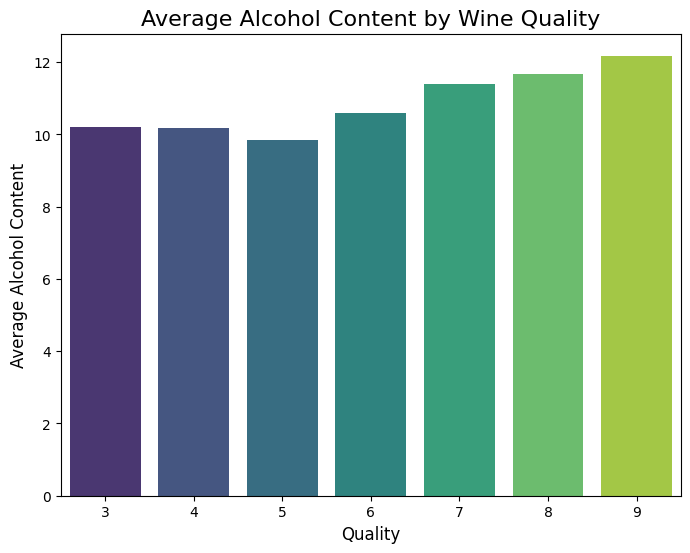

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
df=mergeddata
avg_alcohol = df.groupby('quality')['alcohol'].mean().reset_index()

plt.figure(figsize=(8,6))
sns.barplot(x='quality', y='alcohol', data=avg_alcohol, palette='viridis')

plt.title('Average Alcohol Content by Wine Quality', fontsize=16)
plt.xlabel('Quality', fontsize=12)
plt.ylabel('Average Alcohol Content', fontsize=12)

plt.show()

## Scatter plot

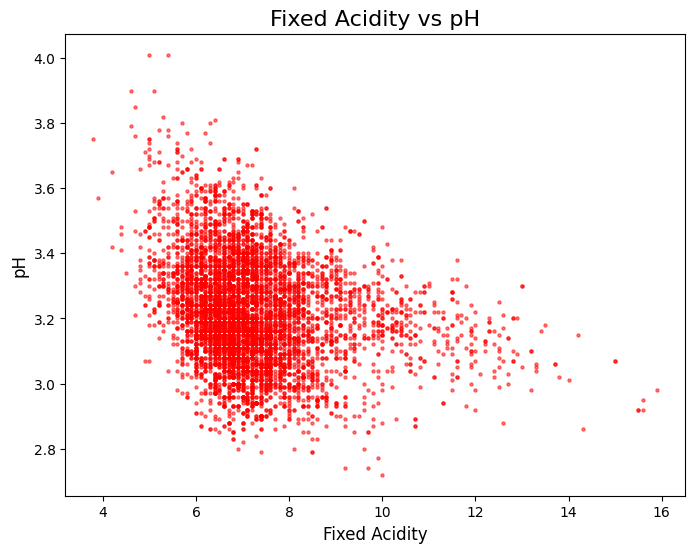

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(df['fixed acidity'], df['pH'], s = 5, alpha=0.5, color='red')

plt.title('Fixed Acidity vs pH', fontsize=16)
plt.xlabel('Fixed Acidity', fontsize=12)
plt.ylabel('pH', fontsize=12)

plt.show()

## Histogram

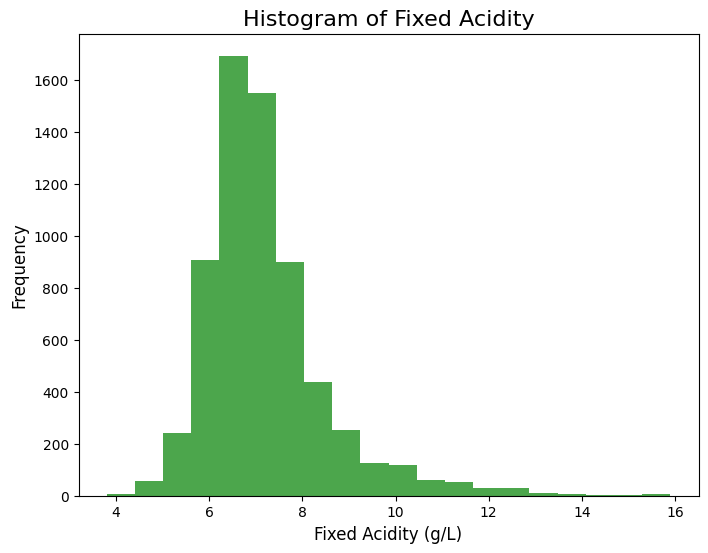

In [ ]:
plt.figure(figsize=(8,6))
plt.hist(df['fixed acidity'], bins=20, alpha=0.7, color='green')

plt.title('Histogram of Fixed Acidity', fontsize=16)
plt.xlabel('Fixed Acidity (g/L)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.show()

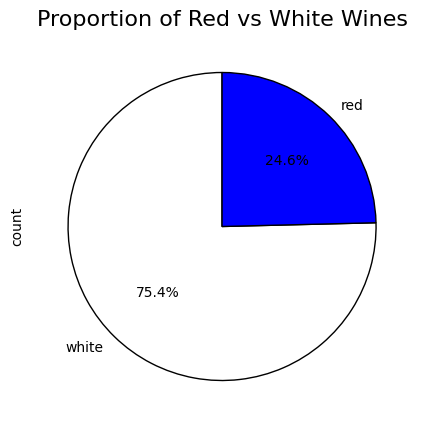

In [ ]:
wine_type_counts = df['type'].value_counts()

plt.figure(figsize=(5, 5))
wine_type_counts.plot.pie(autopct='%1.1f%%', colors=['white', 'blue'], startangle=90, wedgeprops={'edgecolor': 'black'})

plt.title('Proportion of Red vs White Wines', fontsize=16)

plt.show()

# **Expt 7 & 8** (Filter methods of feature selection)

## Information Gain

In [ ]:
from sklearn.feature_selection import mutual_info_classif

X = df.drop(df.columns[-2], axis=1)
y = df.iloc[:, -2]

info_gains = mutual_info_classif(X, y)

print("Information Gain for each feature:")
for feature, gain in zip(df.columns[:-1], info_gains):
    print(f"{feature}: {gain}")

Information Gain for each feature:
fixed acidity: 0.12596413338499213
volatile acidity: 0.23190780741696204
citric acid: 0.1076694966129601
residual sugar: 0.21390274234071116
chlorides: 0.35838051359495626
free sulfur dioxide: 0.1637076410070557
total sulfur dioxide: 0.350724453267117
density: 0.1466269109029481
pH: 0.06290838028055212
sulphates: 0.14731960841192038
alcohol: 0.01944648843010377
quality: 0.007155091381911394
type: 0.5592564157977818


## Chi-Square Test

In [ ]:
from sklearn.feature_selection import SelectKBest, chi2
X = df.drop(df.columns[-2], axis=1)
y = df.iloc[:, -2]
chi2_selector = SelectKBest(score_func=chi2, k="all")
chi2_selector.fit(X, y)

SelectKBest(k='all', score_func=<function chi2 at 0x7bd66108f4c0>)

In [ ]:
chi2_scores = chi2_selector.scores_

In [ ]:
sorted_features = sorted(zip(X.columns, chi2_scores), key=lambda x: x[1], reverse=True)

In [ ]:
print("Feature Chi-Square Scores:")
for feature, score in sorted_features:
    print(f"{feature}: {score:.2f}")

Feature Chi-Square Scores:
total sulfur dioxide: 87946.25
free sulfur dioxide: 14913.55
residual sugar: 3287.06
type_label_encoded: 1599.00
fixed acidity: 358.50
volatile acidity: 221.06
sulphates: 64.27
chlorides: 37.40
citric acid: 15.12
quality: 12.12
pH: 5.65
alcohol: 0.96
density: 0.01


## Pearson's Coefficient

In [ ]:
X = df.iloc[: , :-2]
y = df.iloc[:, -1]
correlation_scores = X.corrwith(y)

In [ ]:
sorted_features = sorted(zip(X.columns, correlation_scores.abs()), key=lambda x: x[1], reverse=True)
print("Feature Correlation Scores:")
for feature, score in sorted_features:
    print(f"{feature}: {score:.4f}")

Feature Correlation Scores:
total sulfur dioxide: 0.7004
volatile acidity: 0.6530
chlorides: 0.5127
sulphates: 0.4872
fixed acidity: 0.4867
free sulfur dioxide: 0.4716
density: 0.3906
residual sugar: 0.3488
pH: 0.3291
citric acid: 0.1874
quality: 0.1193
alcohol: 0.0330


## Variance Threshold

In [ ]:
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold()
selector.fit(X)

VarianceThreshold()

In [ ]:
feature_variances = selector.variances_
sorted_features = sorted(zip(X.columns, feature_variances), key=lambda x: x[1], reverse=True)
print("Feature Variance Scores:")
for feature, score in sorted_features:
    print(f"{feature}: {score:.2f}")

Feature Variance Scores:
total sulfur dioxide: 434.00
free sulfur dioxide: 288.00
residual sugar: 22.63
fixed acidity: 1.68
alcohol: 1.42
quality: 0.76
volatile acidity: 0.03
pH: 0.03
sulphates: 0.02
citric acid: 0.02
chlorides: 0.00
density: 0.00


# **Expt 9 & 10** (wrapping methods of feature selection)

In [ ]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type,type_label_encoded
0,3.8,0.310,0.02,11.1,0.036,20.0,114.0,0.99248,3.75,0.44,12.4,6,white,1
1,3.9,0.225,0.40,4.2,0.030,29.0,118.0,0.98900,3.57,0.36,12.8,8,white,1
2,4.2,0.170,0.36,1.8,0.029,93.0,161.0,0.98999,3.65,0.89,12.0,7,white,1
3,4.2,0.215,0.23,5.1,0.041,64.0,157.0,0.99688,3.42,0.44,8.0,3,white,1
4,4.4,0.320,0.39,4.3,0.030,31.0,127.0,0.98904,3.46,0.36,12.8,8,white,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,15.5,0.645,0.49,4.2,0.095,10.0,23.0,1.00315,2.92,0.74,11.1,5,red,0
6493,15.5,0.645,0.49,4.2,0.095,10.0,23.0,1.00315,2.92,0.74,11.1,5,red,0
6494,15.6,0.645,0.49,4.2,0.095,10.0,23.0,1.00315,2.92,0.74,11.1,5,red,0
6495,15.6,0.685,0.76,3.7,0.100,6.0,43.0,1.00320,2.95,0.68,11.2,7,red,0


In [ ]:
#X = df.drop(df.columns[-2], axis=1)
#X = df.iloc[: , :-2]
#y = df.iloc[:, -1]
#print(y)

0       1
1       1
2       1
3       1
4       1
       ..
6492    0
6493    0
6494    0
6495    0
6496    0
Name: type_label_encoded, Length: 6497, dtype: int64


## forward selection

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression

X = df.iloc[: , :-2]
y = df.iloc[:, -2]

model = LogisticRegression(max_iter=1000)

sfs = SequentialFeatureSelector(model, n_features_to_select='auto', direction='forward', cv=5)
sfs.fit(X, y)

selected_features = X.columns[sfs.get_support()]
print("Selected Features using Forward Selection:")
print(selected_features)

Selected Features using Forward Selection:
Index(['volatile acidity', 'chlorides', 'total sulfur dioxide', 'pH',
       'sulphates', 'alcohol'],
      dtype='object')


## backward elimination

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression

X = df.iloc[: , :-2]
y = df.iloc[:, -2]



model = LogisticRegression(max_iter=1000)


sfs = SequentialFeatureSelector(model, n_features_to_select='auto', direction='backward', cv=5)
sfs.fit(X, y)


selected_features = X.columns[sfs.get_support()]
print("Selected Features using Backward Elimination:")
print(selected_features)

Selected Features using Backward Elimination:
Index(['volatile acidity', 'chlorides', 'total sulfur dioxide', 'pH',
       'sulphates', 'alcohol'],
      dtype='object')


## Recursive elimination

In [ ]:
from sklearn.feature_selection import RFE

X = df.iloc[: , :-2]
y = df.iloc[:, -2]

model = LogisticRegression(max_iter=1000)

rfe = RFE(model, n_features_to_select=5)
rfe.fit(X, y)

selected_features = X.columns[rfe.support_]
print("Selected Features using Recursive Feature Elimination:")
print(selected_features)

Selected Features using Recursive Feature Elimination:
Index(['volatile acidity', 'citric acid', 'chlorides', 'pH', 'sulphates'], dtype='object')


# **Expt 11** (embedding method for feature selection)

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split

X = df.iloc[: , :-2]
y = df.iloc[:, -1]
lasso_model = Lasso(alpha=1.0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lasso_model.fit(X_train, y_train)

print("Coefficients:", lasso_model.coef_)

test_score = lasso_model.score(X_test, y_test)
print(f"Lasso Regression Test Score: {test_score:.3f}")


Coefficients: [-0.         -0.          0.          0.         -0.         -0.
  0.00510309 -0.         -0.         -0.          0.          0.        ]
Lasso Regression Test Score: 0.468


In [ ]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


X, y = make_regression(n_samples=1000, n_features=10, n_informative=5, random_state=1)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

gbr_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gbr_model.fit(X_train, y_train)

y_pred = gbr_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")


Mean Squared Error: 229.07
